### Multiple Linear Regression


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [5]:
from sklearn.datasets import fetch_california_housing

In [10]:
california = fetch_california_housing()

In [11]:
california

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [12]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [13]:
print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [14]:
california.target_names

['MedHouseVal']

In [15]:
print(california.data)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


In [16]:
print(california.target)

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [17]:
#Explore features
california.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [21]:
dataset = pd.DataFrame(california.data, columns = california.feature_names)
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
#find null values in dataset
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [23]:
dataset.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [24]:
dataset.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [26]:
dataset.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000


In [28]:
import seaborn as sns
sns.heatmap(dataset.corr(), annot = True)

<Axes: >

In [29]:
## Find Dependent and Independent Features
X = dataset.iloc[:,:-1]
y = dataset.iloc[:, -1]


In [30]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85


In [ ]:
X_train ,X_test, y_train,y_test = train_test_split(X,y, test_size=0.33, random_state= 10) 

In [32]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
X_train
X_test

array([[ 0.75154854, -1.31428337, -0.39376169, ..., -0.8953542 ,
         0.12606697, -0.68820027],
       [ 0.05935857, -0.12595418, -0.33070668, ...,  0.39561612,
        -0.12021013,  0.89459042],
       [ 0.34405687, -1.31428337, -0.41007104, ...,  0.42718876,
        -0.15581759, -0.91698123],
       ...,
       [ 0.36483158,  0.27015554,  0.04216837, ..., -0.52437564,
        -0.08014641, -0.46875731],
       [-0.90412152, -0.91817364,  0.66736933, ..., -0.7971282 ,
        -0.10263685,  2.51006411],
       [-0.43377577,  1.22081889, -0.44835491, ..., -0.15515111,
         0.2807072 , -0.74422826]])

## Model Training

In [34]:
regression = LinearRegression()

In [35]:
regression.fit(X_train, y_train)


LinearRegression()

In [37]:
##Find slopes of coefficents
regression.coef_

array([-0.38326675, -0.20197421,  0.46922499, -0.26907594, -0.05145997,
        0.02531666, -1.92517105])

In [38]:
## Intercept
regression.intercept_

np.float64(-119.57109560312409)

In [39]:
y_pred = regression.predict(X_test)

In [40]:
y_pred

array([-118.33276226, -121.46886088, -117.88748216, ..., -118.71442746,
       -123.80080501, -118.41853118])

## Performance Metrics

In [41]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [44]:
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(np.sqrt(mean_squared_error(y_test, y_pred)))

0.45615754648066353
0.494295180119168
0.675394363672561


## calculate R square and adjusted R square 

In [46]:
from sklearn.metrics import r2_score
score= r2_score(y_test, y_pred)
print(score)

0.8856648038343249


In [48]:
## Adjusted R Square
# Dsiplay adjusted R-Squared
1- (1-score)*(len(y_test)-1)/ (len(y_test)-X_test.shape[1]-1)

0.8855471750316853

## Assumptions

In [50]:
plt.scatter(y_test, y_pred)
plt.xlabel("Test RTruth Data")
plt.ylabel("Test Predicted_Data")

Text(-13.777777777777784, 0.5, 'Test Predicted_Data')

In [51]:
residuals = y_test - y_pred

In [52]:
residuals

20303   -0.847238
16966   -0.841139
10623    0.117482
6146     0.247380
2208     0.443101
           ...   
13490    0.372862
9340    -0.812999
17439   -1.735573
2602     0.280805
7180     0.238531
Name: Longitude, Length: 6812, dtype: float64

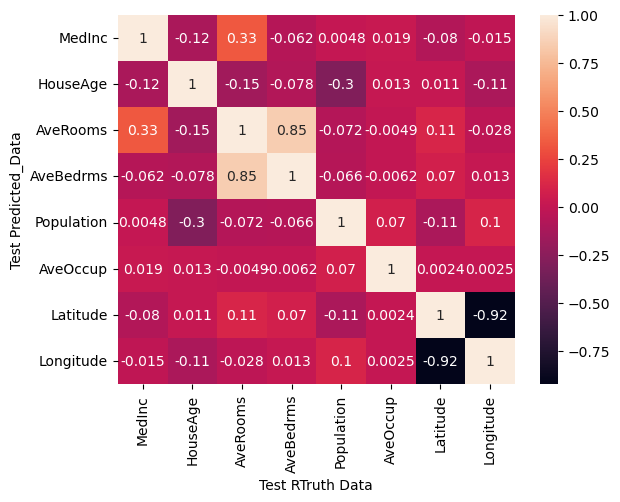

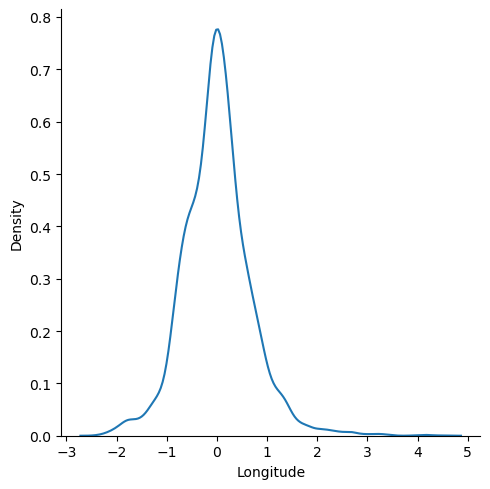

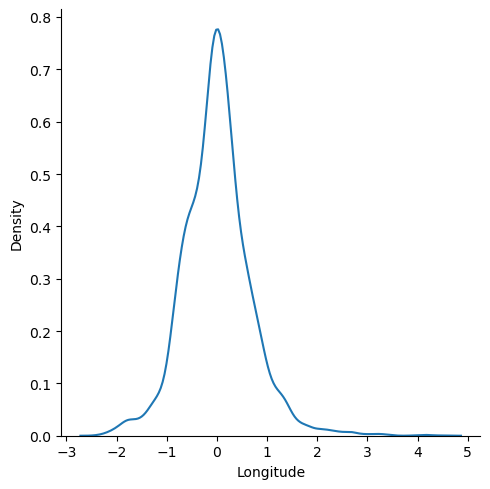

In [54]:
sns.displot(residuals, kind = 'kde')
plt.show()

In [56]:
regression

LinearRegression()

## Pickling.


WHile there is a lot to talk about pickling, for now we can assume that we are storing the model in a file so that we dont need to rerun the whole file for the result. (as training in real scenarios takes hours, days, even months, so running each file when a user uses an aplication is impractical, where pickle serves as best for saving the time)

In [57]:
import pickle
pickle.dump(regression, open('regressor.pkl', 'wb'))

In [58]:
model= pickle.load(open('regressor.pkl', 'rb'))

In [59]:
model.predict(X_test)

array([-118.33276226, -121.46886088, -117.88748216, ..., -118.71442746,
       -123.80080501, -118.41853118])